In [10]:
import pandas as pd
import numpy as np

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
import kagglehub
import os
import pandas as pd

# Download Heart Disease Dataset
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Dataset Path:", path)

100%|██████████| 6.18k/6.18k [00:00<00:00, 3.13MB/s]

Extracting files...
Dataset Path: C:\Users\madha\.cache\kagglehub\datasets\johnsmith88\heart-disease-dataset\versions\2


In [4]:
files = os.listdir(path)
print(files)

# Load dataset
data = pd.read_csv(os.path.join(path, "heart.csv"))

data.head()

['heart.csv']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print(data.shape)
print(data.info())
print(data.describe())

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611

In [6]:
data = data.replace('?', np.nan)
data = data.dropna()

data = data.apply(pd.to_numeric)

# Convert target variable to binary
data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
data['age'] = pd.cut(data['age'], bins=3, labels=[0,1,2])
data['trestbps'] = pd.cut(data['trestbps'], bins=3, labels=[0,1,2])
data['chol'] = pd.cut(data['chol'], bins=3, labels=[0,1,2])
data['thalach'] = pd.cut(data['thalach'], bins=3, labels=[0,1,2])
data['oldpeak'] = pd.cut(data['oldpeak'], bins=3, labels=[0,1,2])

data = data.astype(int)

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1,1,0,0,0,0,1,2,0,0,2,2,3,0
1,1,1,0,1,0,1,0,1,1,1,0,0,3,0
2,2,1,0,1,0,0,1,1,1,1,0,0,3,0
3,1,1,0,1,0,0,1,2,0,0,2,1,3,0
4,2,0,0,1,1,1,1,0,0,0,1,3,2,0


In [8]:
train_data, test_data = train_test_split(
    data,
    test_size=0.3,
    random_state=42
)

In [13]:
model = DiscreteBayesianNetwork([
('age','target'),
('sex','target'),
('cp','target'),
('trestbps','target'),
('chol','target'),
('fbs','target'),
('restecg','target'),
('thalach','target'),
('exang','target'),
('oldpeak','target'),
('slope','target'),
('ca','target'),
('thal','target')
])

In [14]:
model.fit(train_data, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'target': 'N'}


In [15]:
inference = VariableElimination(model)

In [17]:
y_true = []
y_pred = []

for index, row in test_data.iterrows():

    evidence = row.drop('target').to_dict()

    # Keep only evidence states that exist in the fitted CPDs
    filtered_evidence = {}
    for var, val in evidence.items():
        allowed_states = {int(s) for s in model.get_cpds(var).state_names[var]}
        if int(val) in allowed_states:
            filtered_evidence[var] = int(val)

    result = inference.query(
        variables=['target'],
        evidence=filtered_evidence,
        show_progress=False
    )

    prediction = np.argmax(result.values)

    y_true.append(row['target'])
    y_pred.append(prediction)

In [18]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy of Bayesian Network:", accuracy*100)

Accuracy of Bayesian Network: 94.15584415584416


Training Samples: 717
Testing Samples: 308
Accuracy: 0.9415584415584416
Precision: 1.0
Recall: 0.8791946308724832
F1 Score: 0.9357142857142857
[[159   0]
 [ 18 131]]


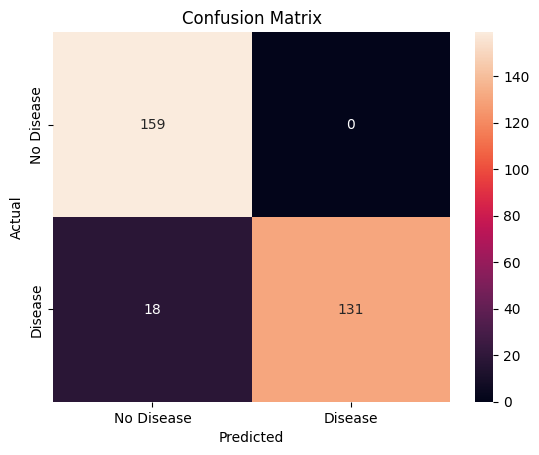

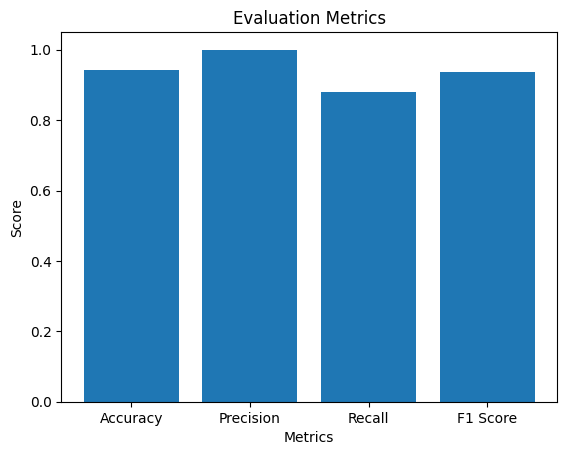

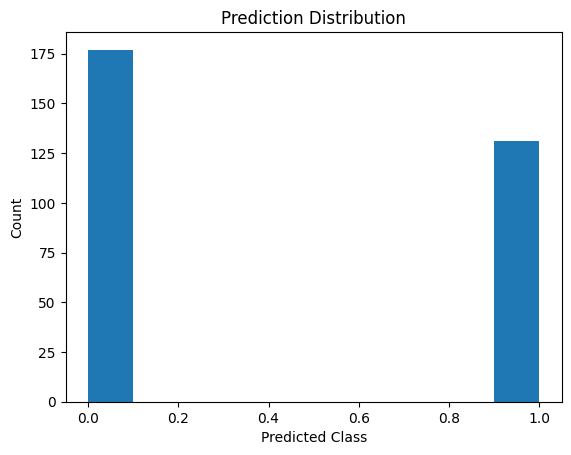

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Samples:", train_data.shape[0])
print("Testing Samples:", test_data.shape[0])

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure()

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

metrics = ["Accuracy","Precision","Recall","F1 Score"]
values = [accuracy, precision, recall, f1]

plt.figure()

plt.bar(metrics, values)

plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.xlabel("Metrics")

plt.show()

plt.figure()

plt.hist(y_pred)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")

plt.show()